# Fourier transforms (a first look)
Spectral analysis is about of signal processing. We can have spatial signals or temporal signals, also for example plane waves can vary in both space and time. All these signals are in real space.

Now, when talking about Fourier space (frequency space), we convert the real signals by carrying out a Fourier transform. We get the characteristic frequencies of the signal.

A Fourier transform is a mathematical method to extract the characteristic frequencies (spatial or temporal) of signals. The signals can be n-dimensional in general. The usual definition is for continuous signals, but computationally we need to discretize it. By doing a Fourier transform, you can even find the frequency information for functions that are not periodic.

## Example:
1. Consider the signal:

$f(t)=\sin(0.8\,t) + \cos(2.5\,t)$,


which consists of the linear combination of two functions:

$f_1(t) = \sin(\omega_1\,t) = \sin(2\,\pi\,\nu_1\,t) = \sin(0.8\,t)$


$f_2(t) = \cos(\omega_2\,t) = \cos(2\,\pi\,\nu_2\,t) = \cos(2.5\,t)$

In [1]:
import numpy as np

import matplotlib.pyplot as plt

In [2]:
# Compute frequencies

def frequency(w):
    """
    Function to compute nu from omega.
    """
    return w/(2*np.pi)

In [3]:
# Define angular frequencies

w_1 = 0.8
w_2 = 2.5

In [4]:
# Call our function to get nu
nu_1 = frequency(w_1)
nu_2 = frequency(w_2)

print("Characteristic frequencies: ", nu_1, nu_2)

Characteristic frequencies:  0.12732395447351627 0.3978873577297384


# Plot of the original function:

In [5]:
# Define function for superposition

def function(t):
    """
    Function to compute f(t)
    """
    return np.sin(w_1*t) + np.cos(w_2*t)

In [6]:
# t_axis for plotting
t = np.linspace(0, 20*np.pi, 1000, endpoint=True)

#define range for x and y
axes_range = [0, 20*np.pi, -5, 5]

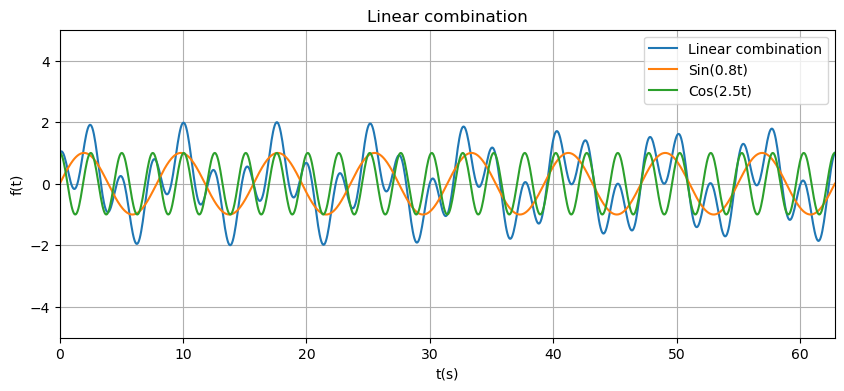

In [7]:
#plotting
plt.figure(figsize = (10, 4))
plt.plot(t, function(t), label = "Linear combination")
plt.plot(t, np.sin(0.8*t), label = "Sin(0.8t)")
plt.plot(t, np.cos(2.5*t), label = "Cos(2.5t)")
plt.title('Linear combination')
plt.legend()
plt.xlabel('t(s)')
plt.xlim(0,np.pi/2)
plt.ylabel('f(t)')
plt.axis(axes_range)
plt.grid()
plt.show()


### Fourier analysis:

https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html

In [8]:
print(t.size)

1000


In [9]:
# Direct FFT
F = np.fft.fft(function(t), t.size)
# print(F)

# Get the magnitude of the complex numbers
F_norm = np.abs(F)
print(t.size, F.size)

#print(F_norm)

1000 1000


We get an array of complex numbers.

### Fourier-space plot:

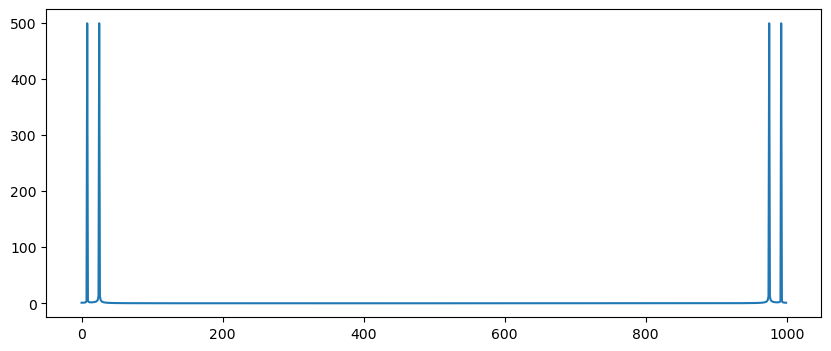

In [10]:
plt.figure(figsize=(10,4))

plt.plot(F_norm)

plt.show()

We do not see the correct amplitudes. We have four peaks since in the periodic domain we're also seeing the mirror of the domain.

## Calculate frequencies:
https://numpy.org/doc/2.2/reference/generated/numpy.fft.fftfreq.html

In [11]:
# n_f
n_f = t.size
# d_f
d_f = 20*np.pi/n_f #last time term over number of elements

print("The correct n is: ", n_f)
print("The sampling rate d is: ", d_f)

The correct n is:  1000
The sampling rate d is:  0.06283185307179587


In [12]:
freqs = np.fft.fftfreq(n_f, d_f) #The sampling rate MUST be fed

print(freqs) #the values are mirrored, first 0 and positive values and then the negative ones

[ 0.          0.01591549  0.03183099  0.04774648  0.06366198  0.07957747
  0.09549297  0.11140846  0.12732395  0.14323945  0.15915494  0.17507044
  0.19098593  0.20690143  0.22281692  0.23873241  0.25464791  0.2705634
  0.2864789   0.30239439  0.31830989  0.33422538  0.35014087  0.36605637
  0.38197186  0.39788736  0.41380285  0.42971835  0.44563384  0.46154933
  0.47746483  0.49338032  0.50929582  0.52521131  0.54112681  0.5570423
  0.5729578   0.58887329  0.60478878  0.62070428  0.63661977  0.65253527
  0.66845076  0.68436626  0.70028175  0.71619724  0.73211274  0.74802823
  0.76394373  0.77985922  0.79577472  0.81169021  0.8276057   0.8435212
  0.85943669  0.87535219  0.89126768  0.90718318  0.92309867  0.93901416
  0.95492966  0.97084515  0.98676065  1.00267614  1.01859164  1.03450713
  1.05042262  1.06633812  1.08225361  1.09816911  1.1140846   1.1300001
  1.14591559  1.16183108  1.17774658  1.19366207  1.20957757  1.22549306
  1.24140856  1.25732405  1.27323954  1.28915504  1.305

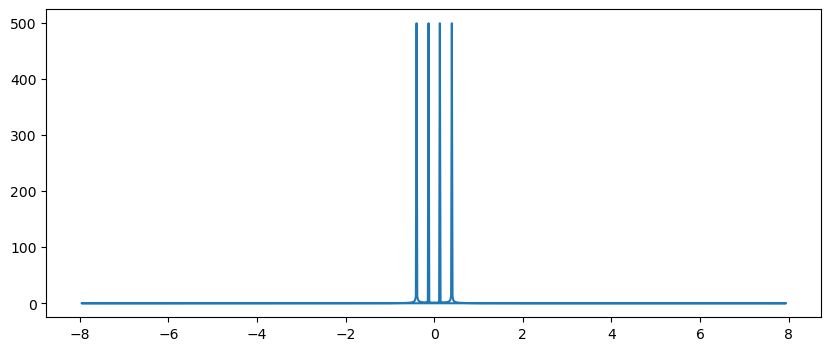

In [13]:
plt.figure(figsize=(10,4))

plt.plot(freqs, F_norm)

plt.show()

### Correcting the amplitudes:
THE AMPLITUDES SHOULD NOT CHANGE IN FOURIER SPACE.

In [14]:
print(F_norm.size//2)

500


In [15]:
#Normalize
F_norm_c = F_norm/(F_norm.size//2)

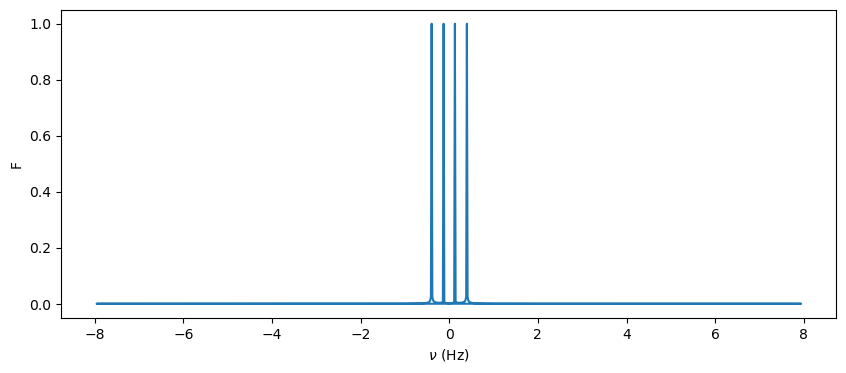

In [16]:
plt.figure(figsize=(10,4))

plt.plot(freqs, F_norm_c)

#plt.xlim(0,1)

plt.xlabel(r'$\nu$ (Hz)')
plt.ylabel('F')
plt.show()

We're normally interested in the positive frequencies.

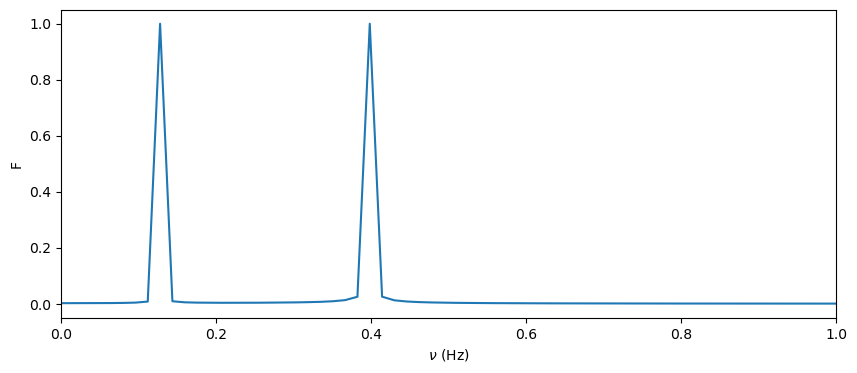

In [17]:
plt.figure(figsize=(10,4))

plt.plot(freqs[0:freqs.size//2], (2/F_norm.size)*F_norm[0:F_norm.size//2])
# plt.plot(freqs[0:freqs.size//2], F_norm_c[0:F_norm.size//2])

plt.xlim(0,1)

plt.xlabel(r'$\nu$ (Hz)')
plt.ylabel('F')
plt.show()

In [18]:
print(nu_1, nu_2)

0.12732395447351627 0.3978873577297384


### Peak finding:

In [19]:
from scipy.signal import find_peaks

In [20]:
amp_Fm = (2/F_norm.size)*F_norm[0:F_norm.size//2]

peaks, properties = find_peaks(amp_Fm, height=0)

print(peaks)

[ 8 25]


In [21]:
print(properties) #these are the peaks amplitudes

{'peak_heights': array([0.99939659, 0.99947223])}


In [22]:
peak_freq1 = freqs[peaks[0]]
peak_freq2 = freqs[peaks[1]]

print(peak_freq1, peak_freq2)

0.12732395447351627 0.3978873577297383


In [23]:
print(nu_1, nu_2)

0.12732395447351627 0.3978873577297384


## Inverse Fourier Transform:
https://numpy.org/doc/2.2/reference/generated/numpy.fft.ifft.html

In [24]:
#inverse fft

iF = np.fft.ifft(F)

In [25]:
#print(iF)

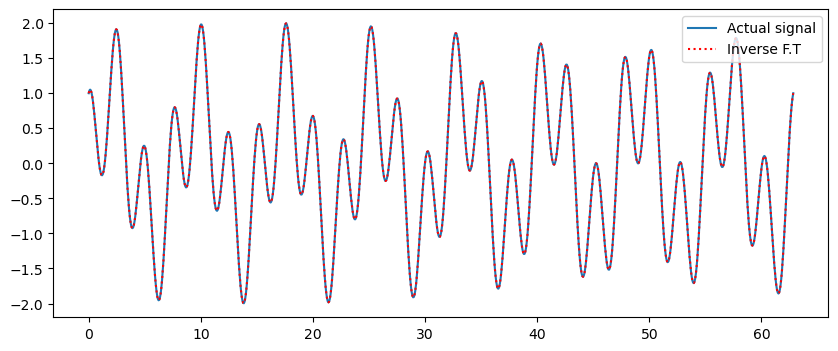

In [26]:
plt.figure(figsize = (10, 4))

plt.plot(t, function(t), linestyle = '-', label = "Actual signal")
plt.plot(t, iF.real, linestyle = ':', color = 'red', label = "Inverse F.T") #plot the real part of the inverse fourier transform

plt.legend()
plt.show()

We have decomposed the signal in its characteristic frequencies.

 $\Rightarrow$ How many waves conform the signal and what are their characteristic frequencies?

# Exercise:


Calculate the characteristic frequencies of the following series, where the amplitude and frequencies change:

$y(t)=\sum_{i = 1}^n i\,\cos(i\alpha\,t)$, with $\alpha = 20\pi$

(a) Compute them analytically first.

(b) Then, using Fourier transforms.

In [27]:
def function_series(t, a, n):
    # t is the time axis
    # a = 20*pi
    # n is a free parameter, from 0 to n
    
    nu = []
    f = np.zeros(t.size)
    
    for i in range(n+1):
        
        y = i*np.cos(i*a*t)
        
        #Analytical frequencies
        nu.append(i*a/(2*np.pi))
        
        f += y

    # Fourier Analysis
    F_n = np.fft.fft(f, t.size)
    F_m = np.abs(F_n)
    freqs = np.fft.fftfreq(t.size, np.pi/10000) #recall that the sampling rate depends on the size and endpoint of the x-vector
        
    nu = np.array(nu)    
    return f, nu, freqs, F_m

In [28]:
t = np.linspace(0, np.pi, 10000, endpoint=True)

a = 20*np.pi
n = 5
y_result, nu_result, freqs_result, F_result = function_series(t, a, n)

In [29]:
print(y_result.shape, nu_result.shape, freqs_result.shape, F_result.shape)

(10000,) (6,) (10000,) (10000,)


In [30]:
print("Characteristic frequencies:",  nu_result)

Characteristic frequencies: [ 0. 10. 20. 30. 40. 50.]


### Plot of the signal:

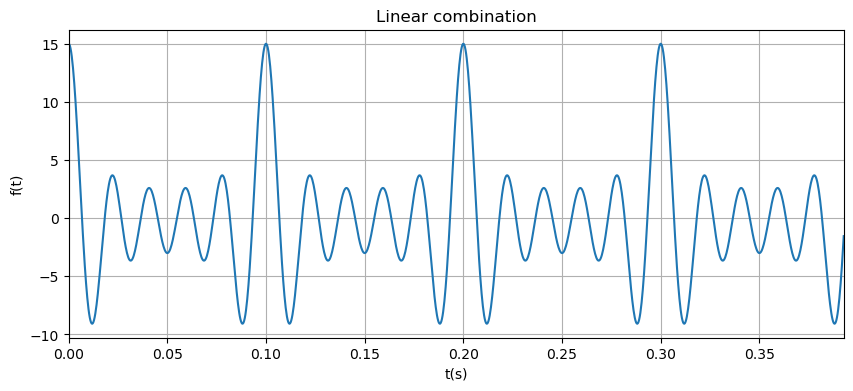

In [31]:
#Plotting
plt.figure(figsize = (10, 4))

plt.plot(t, y_result)
plt.title('Linear combination')
plt.xlim(0, np.pi/8)
plt.xlabel('t(s)')
plt.ylabel('f(t)')

#plt.axis(axes_range)
plt.grid()
plt.show()

### Fourier transform of the signal:

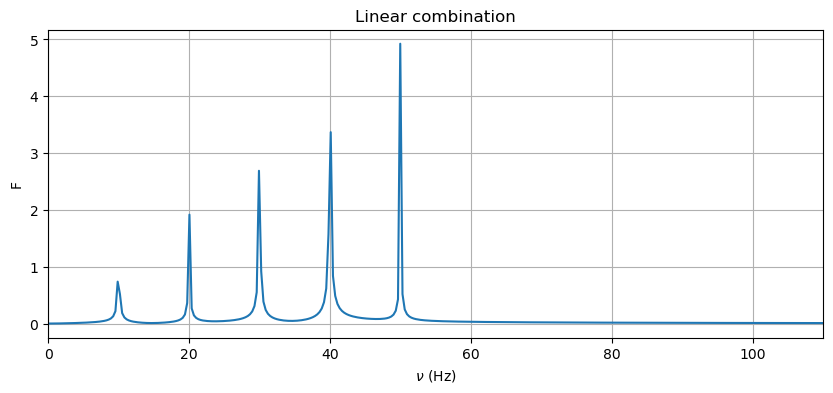

In [32]:
#plotting
plt.figure(figsize = (10, 4))

plt.plot(freqs_result[0:freqs_result.size//2], (2/F_result.size)*F_result[0:F_result.size//2]) #positive range only
plt.title('Linear combination')
plt.xlim(0, 110)
plt.xlabel(r'$\nu$ (Hz)')
plt.ylabel('F')

#plt.axis(axes_range)
plt.grid()
plt.show()

### Finding the peaks:

In [33]:
amp_Fm = (2/F_result.size)*F_result[0:F_result.size//2]

peaks, properties = find_peaks(amp_Fm, height=0)

print(peaks)

[ 31  63  94 126 157]


In [34]:
all_Peaks = freqs_result[peaks]

print("Characteristic frequencies from FFT: ", all_Peaks)

Characteristic frequencies from FFT:  [ 9.86760647 20.05352283 29.9211293  40.10704566 49.97465213]


In [35]:
print("Input characteristic frequencies:",  nu_result)

Input characteristic frequencies: [ 0. 10. 20. 30. 40. 50.]
